#2. Extracción de Descriptores Clásicos

In [ ]:
!pip install scikit-image --quiet

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from glob import glob
import shutil
from tqdm import tqdm
import random

In [ ]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/chest_xray_preprocessed"
train_normal = glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal))
print("PNEUMONIA train:", len(train_pneu))

NORMAL train: 1341
PNEUMONIA train: 3875


In [ ]:
#Ruta de salida

FEATURES_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features"

os.makedirs(FEATURES_PATH, exist_ok=True)

subsets = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
label_map = {"NORMAL": 0, "PNEUMONIA": 1}

In [ ]:
#Ruta da salida de imágenes
results_dir="/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/imagenes"
os.makedirs(results_dir, exist_ok=True)


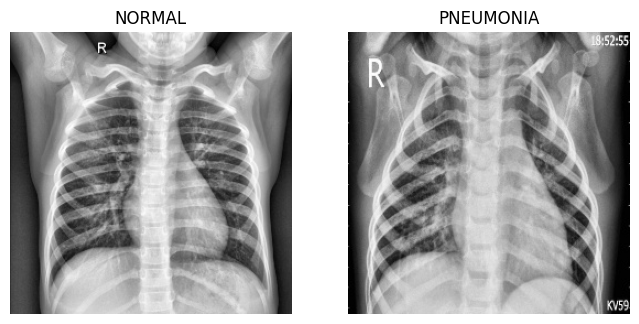

In [ ]:
#Se muestra un ejemplo de ambas clases

# Se elige una imagen de cada clase
sample_normal = train_normal[0]
sample_pneu   = train_pneu[0]

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img

img_normal = load_gray(sample_normal)
img_pneu   = load_gray(sample_pneu)

fig=plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_normal, cmap='gray')
plt.title("NORMAL")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_pneu, cmap='gray')
plt.title("PNEUMONIA")
plt.axis('off')

plt.show()
ruta_guardado = os.path.join(results_dir, "comparacionClases.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)


## 2.1 Descriptores de Forma:

2.1.1. Histogram of Oriented Gradients (HOG)

2.1.2. Momentos de Hu

2.1.3. Descriptores de contorno

2.1.4. Fourier Shape Descriptors

### 2.1.1 Histogram of Oriented Gradients (HOG)

HOG describe qué bordes hay en la imagen, en qué dirección apuntan y con qué fuerza

In [ ]:
#Se define la función para HOG
def compute_hog(img, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2)):
    # img: imagen en escala de grises (numpy 2D)
    hog_features, hog_image = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )

    # Mejorar contraste de la imagen HOG para visualizar
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    return hog_features, hog_image_rescaled


Dimensión descriptor HOG NORMAL: (8100,)
Dimensión descriptor HOG PNEUMONIA: (8100,)


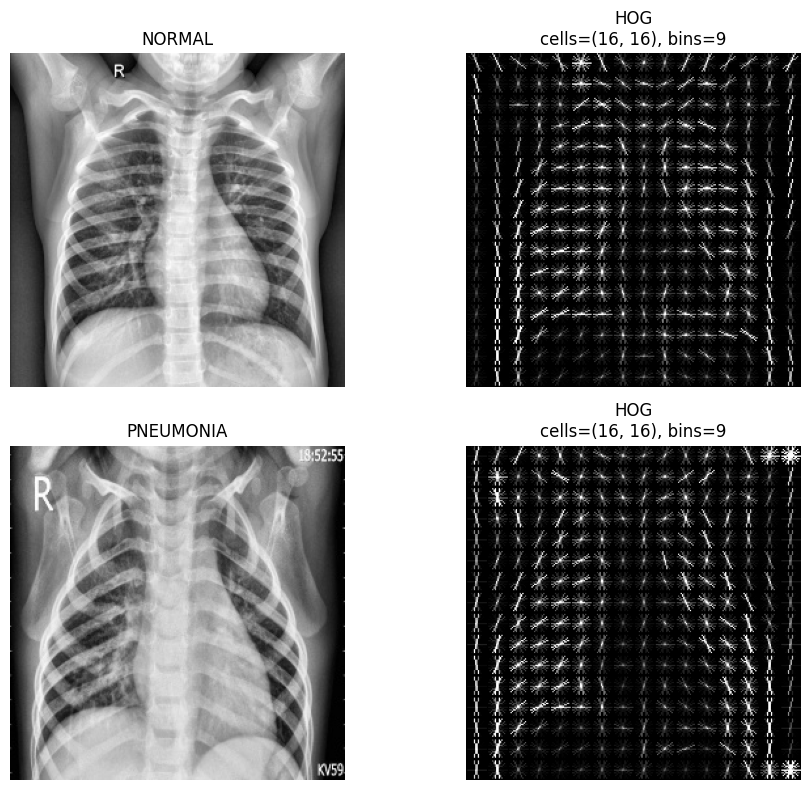

In [ ]:
#Se muestra un ejemplo utilizando:
orientations = 9
pixels_per_cell = (16, 16)
cells_per_block = (2, 2)

hog_feat_normal, hog_img_normal = compute_hog(img_normal, orientations, pixels_per_cell, cells_per_block)
hog_feat_pneu,   hog_img_pneu   = compute_hog(img_pneu, orientations, pixels_per_cell, cells_per_block)

print("Dimensión descriptor HOG NORMAL:", hog_feat_normal.shape)
print("Dimensión descriptor HOG PNEUMONIA:", hog_feat_pneu.shape)

fig=plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(img_normal, cmap='gray')
plt.title("NORMAL")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(hog_img_normal, cmap='gray')
plt.title(f"HOG\ncells={pixels_per_cell}, bins={orientations}")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_pneu, cmap='gray')
plt.title("PNEUMONIA")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(hog_img_pneu, cmap='gray')
plt.title(f"HOG\ncells={pixels_per_cell}, bins={orientations}")
plt.axis('off')

plt.tight_layout()
plt.show()
ruta_guardado = os.path.join(results_dir, "comparacionClasesHOG.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)

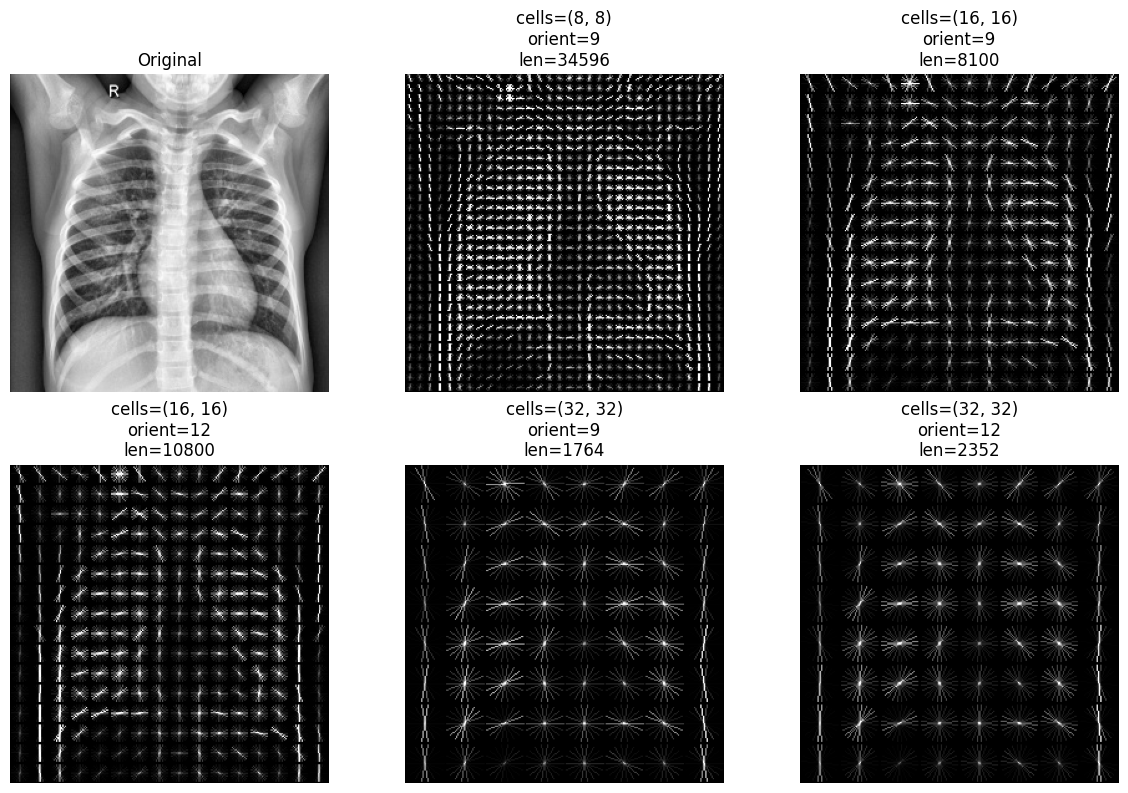

In [ ]:
#Se prueba con diferentes parámetros
param_grid = [
    {"orientations": 9, "pixels_per_cell": (8,8)},
    {"orientations": 9, "pixels_per_cell": (16,16)},
    {"orientations": 12, "pixels_per_cell": (16,16)},
    {"orientations": 9, "pixels_per_cell": (32,32)},
    {"orientations": 12, "pixels_per_cell": (32,32)},
]

img = img_normal  # Se prueba con una imagen sana

fig=plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, params in enumerate(param_grid, start=2):
    feat, hog_img = compute_hog(
        img,
        orientations=params["orientations"],
        pixels_per_cell=params["pixels_per_cell"],
        cells_per_block=(2,2)
    )
    plt.subplot(2,3,i)
    plt.imshow(hog_img, cmap='gray')
    plt.title(f"cells={params['pixels_per_cell']}\norient={params['orientations']}\nlen={len(feat)}")
    plt.axis('off')

plt.tight_layout()
plt.show()
ruta_guardado = os.path.join(results_dir, "comparacionParametrosHOG.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)

In [ ]:
DATASET_PATH_CROP = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped"
train_normal_crop = glob(os.path.join(DATASET_PATH_CROP, "train/NORMAL/*.jpeg"))
train_pneu_crop   = glob(os.path.join(DATASET_PATH_CROP, "train/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal_crop))
print("PNEUMONIA train:", len(train_pneu_crop))

NORMAL train: 1341
PNEUMONIA train: 3875


In [ ]:
# Se elige una imagen de cada clase
sample_normal_crop = train_normal_crop[1]
sample_pneu_crop   = train_pneu_crop[1]

img_normal_crop = load_gray(sample_normal_crop)
img_pneu_crop   = load_gray(sample_pneu_crop)



Dimensión descriptor HOG NORMAL: (34596,)
Dimensión descriptor HOG PNEUMONIA: (34596,)


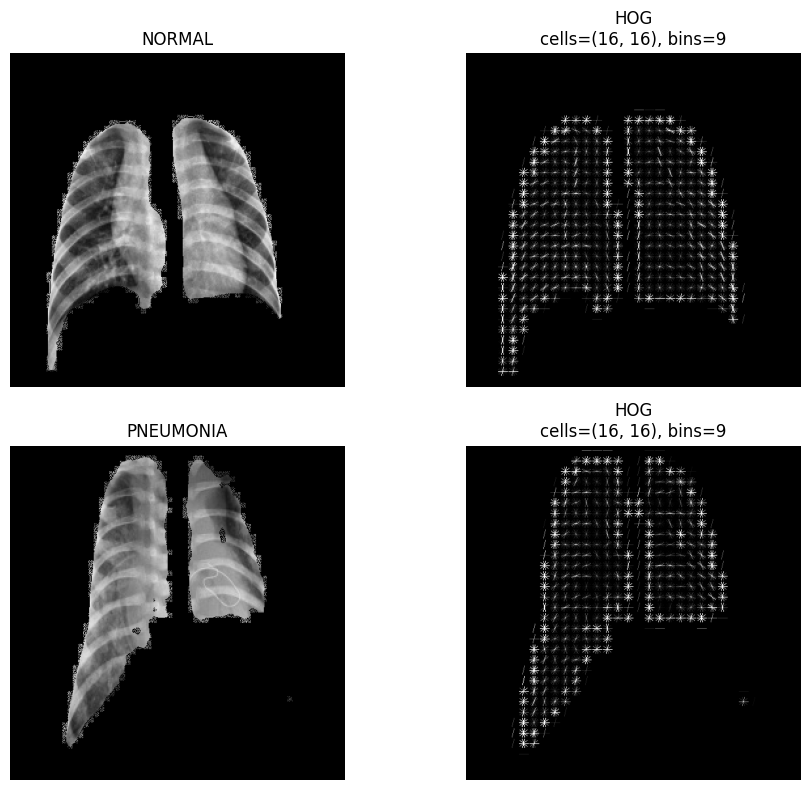

In [ ]:
#Se muestra un ejemplo utilizando:
orientations = 9
pixels_per_cell = (16, 16)
cells_per_block = (2, 2)

hog_feat_normal_crop, hog_img_normal_crop = compute_hog(img_normal_crop, orientations, pixels_per_cell, cells_per_block)
hog_feat_pneu_crop,   hog_img_pneu_crop   = compute_hog(img_pneu_crop, orientations, pixels_per_cell, cells_per_block)

print("Dimensión descriptor HOG NORMAL:", hog_feat_normal_crop.shape)
print("Dimensión descriptor HOG PNEUMONIA:", hog_feat_pneu_crop.shape)

fig=plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(img_normal_crop, cmap='gray')
plt.title("NORMAL")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(hog_img_normal_crop, cmap='gray')
plt.title(f"HOG\ncells={pixels_per_cell}, bins={orientations}")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_pneu_crop, cmap='gray')
plt.title("PNEUMONIA")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(hog_img_pneu_crop, cmap='gray')
plt.title(f"HOG\ncells={pixels_per_cell}, bins={orientations}")
plt.axis('off')

plt.tight_layout()
plt.show()

ruta_guardado = os.path.join(results_dir, "comparacionCropHOG.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)

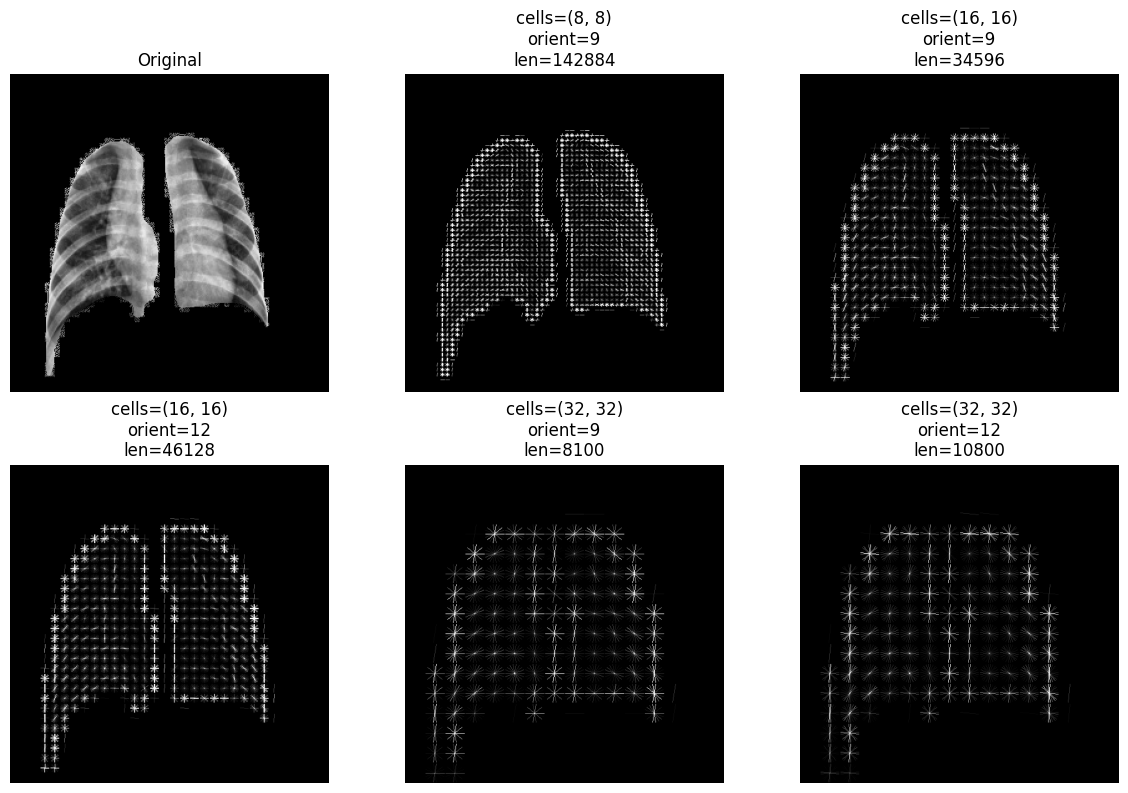

In [ ]:
#Se prueba con diferentes parámetros
param_grid = [
    {"orientations": 9, "pixels_per_cell": (8,8)},
    {"orientations": 9, "pixels_per_cell": (16,16)},
    {"orientations": 12, "pixels_per_cell": (16,16)},
    {"orientations": 9, "pixels_per_cell": (32,32)},
    {"orientations": 12, "pixels_per_cell": (32,32)},
]

img1 = img_normal_crop  # Se prueba con una imagen sana

fig=plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.imshow(img1, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, params in enumerate(param_grid, start=2):
    feat, hog_img = compute_hog(
        img1,
        orientations=params["orientations"],
        pixels_per_cell=params["pixels_per_cell"],
        cells_per_block=(2,2)
    )
    plt.subplot(2,3,i)
    plt.imshow(hog_img, cmap='gray')
    plt.title(f"cells={params['pixels_per_cell']}\norient={params['orientations']}\nlen={len(feat)}")
    plt.axis('off')

plt.tight_layout()
plt.show()
ruta_guardado = os.path.join(results_dir, "comparacionParametrosCropHOG.png")
fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
plt.close(fig)

In [ ]:
#Se guardan los descriptores para todo el dataset CROP

for subset in subsets:
    X_list = []
    y_list = []
    files_list = []

    print(f"\n=== Procesando subset: {subset} ===")

    for cls in classes:
        in_dir = os.path.join(DATASET_PATH_CROP, subset, cls)
        img_paths = glob(os.path.join(in_dir, "*.jpeg"))

        print(f"{subset}/{cls}: {len(img_paths)} imágenes")

        for p in tqdm(img_paths, desc=f"{subset}/{cls}"):
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Se utiliza orientations = 9
            #pixels_per_cell = (16, 16)
            #cells_per_block = (2, 2)

            feats, hog_img = compute_hog(
                img,
                orientations=9,
                pixels_per_cell=(16,16),
                cells_per_block=(2,2)
            )

            X_list.append(feats)
            y_list.append(label_map[cls])
            files_list.append(p)

    # Convertir a arrays
    X = np.vstack(X_list)          # (N, D)
    y = np.array(y_list)           # (N,)
    files = np.array(files_list)   # (N,)

    print(f"{subset}: X shape = {X.shape}, y shape = {y.shape}")

    # Guardar en .npz
    out_path = os.path.join(FEATURES_PATH, f"hog_{subset}.npz")
    np.savez(out_path, X=X, y=y, files=files)

    print(f"Guardado: {out_path}")



=== Procesando subset: train ===
train/NORMAL: 1341 imágenes


train/NORMAL: 100%|██████████| 1341/1341 [05:07<00:00,  4.37it/s]


train/PNEUMONIA: 3875 imágenes


train/PNEUMONIA: 100%|██████████| 3875/3875 [15:55<00:00,  4.05it/s]


train: X shape = (5216, 34596), y shape = (5216,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hog_train.npz

=== Procesando subset: val ===
val/NORMAL: 8 imágenes


...

val: X shape = (16, 34596), y shape = (16,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hog_val.npz

=== Procesando subset: test ===
test/NORMAL: 234 imágenes


test/NORMAL: 100%|██████████| 234/234 [01:05<00:00,  3.57it/s]


test/PNEUMONIA: 390 imágenes


test/PNEUMONIA: 100%|██████████| 390/390 [01:30<00:00,  4.33it/s]


test: X shape = (624, 34596), y shape = (624,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hog_test.npz


### 2.1.2. Momentos de Hu

Los Momentos de Hu son un conjunto de 7 descriptores invariantes de forma basados en momentos centrales normalizados. Proveen invariancia a traslación, escala y rotación, lo que permite comparar formas independientemente de su orientación, tamaño o posición en la imagen.

In [ ]:
DATASET_PATH_mask = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/masks"
train_normal_mask = glob(os.path.join(DATASET_PATH_mask, "train/NORMAL/*.jpeg"))
train_pneu_mask   = glob(os.path.join(DATASET_PATH_mask, "train/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal_mask))
print("PNEUMONIA train:", len(train_pneu_mask))

NORMAL train: 1341
PNEUMONIA train: 3875


In [ ]:
#Se define la función para los momentos de HU
def compute_hu_moments_from_mask(binary_mask):
    """
    binary_mask: imagen binaria uint8 (0 fondo, 255 objeto)
    return:
      hu: 7 momentos originales
      hu_log: 7 momentos log-transformados (recomendados)
    """
    # asegurar 0/255
    _, mask = cv2.threshold(binary_mask, 127, 255, cv2.THRESH_BINARY)

    m = cv2.moments(mask)
    hu = cv2.HuMoments(m).flatten()

    # transformar a log para manejar mejor la escala
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    return hu, hu_log

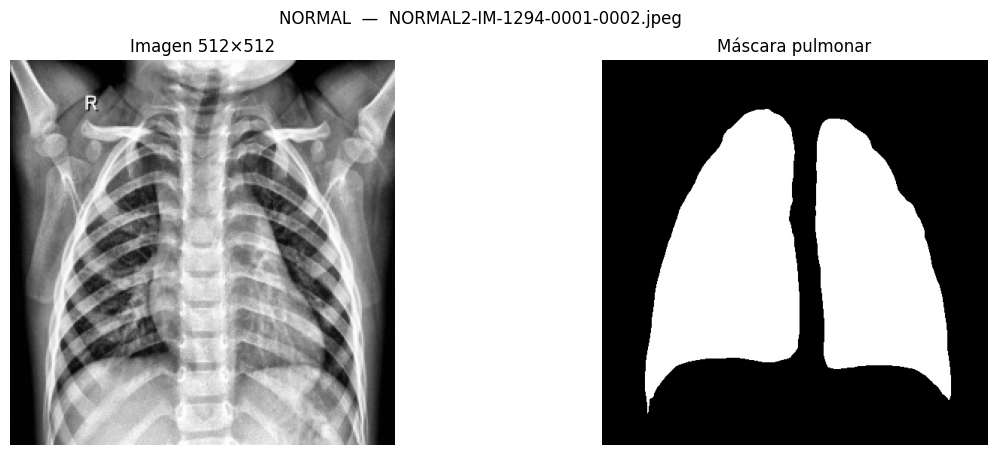

Momentos de Hu (log) para NORMAL:
[  3.09518535   7.74283017   9.91124263  11.36732456 -12.
 -11.99984012 -12.        ] 



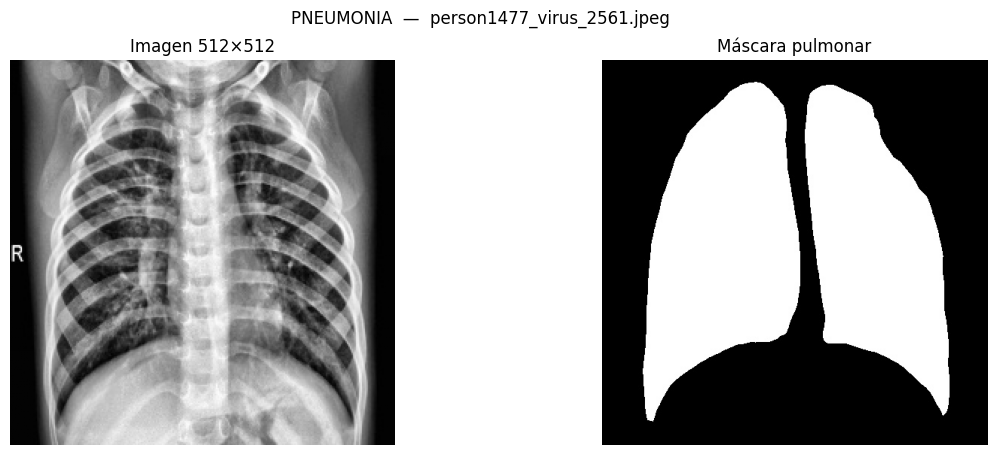

Momentos de Hu (log) para PNEUMONIA:
[  3.09793794   8.06061368   9.94164528  11.05105342 -12.
 -11.99971903 -12.        ] 



In [ ]:
#Ejemplo para una imagen de cada clase
samples = {
    "NORMAL":   random.choice(glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))),
    "PNEUMONIA": random.choice(glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg")))
}

for cls, img_path in samples.items():
    fname = os.path.basename(img_path)
    mask_path = os.path.join(DATASET_PATH_mask, "train", cls, fname)
    crop_mask= os.path.join(DATASET_PATH_CROP, "train", cls, fname)

    img  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)



    _, hu_log = compute_hu_moments_from_mask(mask)

    fig=plt.figure(figsize=(14,5))
    plt.suptitle(f"{cls}  —  {fname}")

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Imagen 512×512")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Máscara pulmonar")
    plt.axis("off")


    plt.show()

    ruta_guardado = os.path.join(results_dir, "imagenMaskHu.png")
    fig.savefig(ruta_guardado, dpi=500, bbox_inches='tight')
    plt.close(fig)

    print(f"Momentos de Hu (log) para {cls}:")
    print(hu_log, "\n")

In [ ]:
#Se guardan los descriptores para todo el dataset masks

for subset in subsets:
    X_list = []
    y_list = []
    files_list = []

    print(f"\n=== Procesando Hu para subset: {subset} ===")

    for cls in classes:
        mask_dir = os.path.join(DATASET_PATH_mask, subset, cls)
        mask_paths = glob(os.path.join(mask_dir, "*.jpeg"))

        print(f"{subset}/{cls}: {len(mask_paths)} máscaras")

        for p in tqdm(mask_paths, desc=f"{subset}/{cls}"):
            mask = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue

            # calcular Hu
            _, hu_log = compute_hu_moments_from_mask(mask)

            X_list.append(hu_log)
            y_list.append(label_map[cls])
            files_list.append(p)

    # convertir a arrays
    X = np.vstack(X_list)        # (N, 7)
    y = np.array(y_list)         # (N,)
    files = np.array(files_list) # (N,)

    print(f"{subset}: X shape = {X.shape}, y shape = {y.shape}")

    # guardar en .npz
    out_path = os.path.join(FEATURES_PATH, f"hu_{subset}.npz")
    np.savez(out_path, X=X, y=y, files=files)
    print("Guardado:", out_path)


=== Procesando Hu para subset: train ===
train/NORMAL: 1341 máscaras


train/NORMAL: 100%|██████████| 1341/1341 [00:43<00:00, 30.65it/s] 


train/PNEUMONIA: 3875 máscaras


train/PNEUMONIA: 100%|██████████| 3875/3875 [02:47<00:00, 23.16it/s] 


train: X shape = (5216, 7), y shape = (5216,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_train.npz

=== Procesando Hu para subset: val ===
val/NORMAL: 8 máscaras


...

val: X shape = (16, 7), y shape = (16,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_val.npz

=== Procesando Hu para subset: test ===
test/NORMAL: 234 máscaras


test/NORMAL: 100%|██████████| 234/234 [00:06<00:00, 34.41it/s] 


test/PNEUMONIA: 390 máscaras


test/PNEUMONIA: 100%|██████████| 390/390 [00:09<00:00, 39.79it/s] 

test: X shape = (624, 7), y shape = (624,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_test.npz


### 2.1.3 Descriptores de contorno
1. Área, perímetro, circularidad, excentricidad

In [ ]:
#Se define la función para extraer los descriptores

def contour_descriptors(mask):
    """
    mask: imagen binaria 0/255 (pulmones segmentados)
    return: area, perimetro, circularidad, excentricidad
    """

    # Asegurar binaria
    _, bin_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Encontrar contornos
    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None, None, None, None

    # Usar el contorno más grande
    cnt = max(contours, key=cv2.contourArea)

    # Área
    area = cv2.contourArea(cnt)

    # Perímetro
    perimeter = cv2.arcLength(cnt, True)

    # Circularidad
    if perimeter == 0:
        circularity = 0
    else:
        circularity = 4 * np.pi * area / (perimeter ** 2)

    # Excentricidad usando elipse ajustada
    eccentricity = None
    if len(cnt) >= 5:
        (x, y), (axes1, axes2), angle = cv2.fitEllipse(cnt)

        # Asegurar que major_axis >= minor_axis
        major_axis = max(axes1, axes2)
        minor_axis = min(axes1, axes2)

        if major_axis > 0:
            ratio = minor_axis / major_axis
            # Recortar por seguridad numérica
            ratio = np.clip(ratio, 0.0, 1.0)
            eccentricity = np.sqrt(1 - ratio**2)
        else:
            eccentricity = 0.0

    return area, perimeter, circularity, eccentricity

Área: 53970.0
Perímetro: 1092.7249563932419
Circularidad: 0.5679898282404551
Excentricidad: 0.9154217532552648


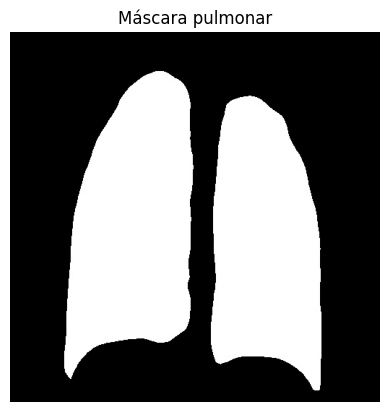

In [ ]:
#Utilizando la última máscara del descriptor anterior, se muestra un ejemplo

area, perimeter, circ, ecc = contour_descriptors(mask)

plt.imshow(mask, cmap="gray")
plt.title("Máscara pulmonar")
plt.axis("off")

print("Área:", area)
print("Perímetro:", perimeter)
print("Circularidad:", circ)
print("Excentricidad:", ecc)

In [ ]:
#Se guarda para todo el dataset

for subset in subsets:
    X_list = []
    y_list = []
    files_list = []

    print(f"\n=== Procesando descriptores de contorno: {subset} ===")

    for cls in classes:
        mask_dir = os.path.join(DATASET_PATH_mask, subset, cls)
        mask_paths = glob(os.path.join(mask_dir, "*.jpeg"))

        print(f"{subset}/{cls}: {len(mask_paths)} máscaras")

        for p in tqdm(mask_paths, desc=f"{subset}/{cls}"):
            mask = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print("Error leyendo:", p)
                continue

            area, peri, circ, ecc = contour_descriptors(mask)

            # Asegurar que no sea None
            if area is None:
                continue

            X_list.append([area, peri, circ, ecc])
            y_list.append(label_map[cls])
            files_list.append(p)

    # Convertir a arrays
    X = np.array(X_list)        # (N, 4)
    y = np.array(y_list)        # (N,)
    files = np.array(files_list)

    print(f"{subset}: X shape = {X.shape}, y shape = {y.shape}")

    # Guardar
    out_path = os.path.join(FEATURES_PATH, f"contour_{subset}.npz")
    np.savez(out_path, X=X, y=y, files=files)

    print("Guardado:", out_path)


=== Procesando descriptores de contorno: train ===
train/NORMAL: 1341 máscaras


train/NORMAL: 100%|██████████| 1341/1341 [00:27<00:00, 49.49it/s] 


train/PNEUMONIA: 3875 máscaras


train/PNEUMONIA: 100%|██████████| 3875/3875 [01:14<00:00, 51.67it/s] 


train: X shape = (5216, 4), y shape = (5216,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_train.npz

=== Procesando descriptores de contorno: val ===
val/NORMAL: 8 máscaras


...

val: X shape = (16, 4), y shape = (16,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_val.npz

=== Procesando descriptores de contorno: test ===
test/NORMAL: 234 máscaras


test/NORMAL: 100%|██████████| 234/234 [00:02<00:00, 88.16it/s] 


test/PNEUMONIA: 390 máscaras


test/PNEUMONIA: 100%|██████████| 390/390 [00:04<00:00, 83.67it/s] 

test: X shape = (624, 4), y shape = (624,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_test.npz


### 2.1.4 Fourier Shape Descriptors
1. Representación en frecuencia del contorno
2. Usar primeros N coeficientes

In [ ]:
#Se define la función FSD

def fourier_descriptors(mask, n_descriptors=20, use_magnitude=True):
    """
    Calcula Fourier Shape Descriptors a partir de una máscara binaria.

    mask: imagen 2D uint8 (0 fondo, 255 objeto)
    n_descriptors: número de coeficientes de baja frecuencia a usar (excluyendo DC)
    use_magnitude: si True -> solo magnitudes (invariante a rotación)
                   si False -> concatenar [Re, Im] (mantiene fase)

    return: vector de características (longitud n_descriptors si use_magnitude=True,
                                      longitud 2*n_descriptors si use_magnitude=False)
    """
    # Asegurar binaria
    _, bin_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Contornos
    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return None

    # Contorno más grande
    cnt = max(contours, key=cv2.contourArea)

    # Puntos
    if cnt.shape[0] < n_descriptors + 1:
        # si el contorno es muy corto, devolver None o rellenar
        return None

    # Convertir a Nx2
    pts = cnt[:, 0, :]       # (N, 2)
    x = pts[:, 0].astype(np.float64)
    y = pts[:, 1].astype(np.float64)

    # Representación compleja
    z = x + 1j * y

    # Quitar traslación: centrar en el origen
    z = z - z.mean()

    # Transformada de Fourier
    Z = np.fft.fft(z)

    # Usar los primeros n_descriptors coeficientes a partir de 1 (baja frecuencia)
    # Asegurar no exceder longitud
    max_k = min(n_descriptors + 1, len(Z))
    Z_low = Z[1:max_k]

    # Normalización de escala: dividir por magnitud del primer coeficiente
    norm = np.abs(Z_low[0]) + 1e-12
    Z_low = Z_low / norm

    if use_magnitude:
        # Invariante a rotación: usar solo magnitudes
        feats = np.abs(Z_low)
    else:
        # Conservar fase: concatenar parte real e imaginaria
        feats = np.concatenate([Z_low.real, Z_low.imag])

    return feats

In [ ]:
#Se prueba con la mask anterior
fsd = fourier_descriptors(mask, n_descriptors=20, use_magnitude=True)
print("Longitud del descriptor FSD:", len(fsd))
print("FSD:", fsd)

Longitud del descriptor FSD: 20
FSD: [1.         0.20798111 0.16755065 0.12457743 0.07452007 0.0438846
 0.02566708 0.01921481 0.01981973 0.0112455  0.00689003 0.00988536
 0.00642878 0.00976752 0.00664809 0.00710578 0.00352025 0.00157852
 0.00208309 0.00229794]


In [ ]:
#Se crea la matriz para todo el dataset

N_FSD = 20   # número de coeficientes

for subset in subsets:
    X_list = []
    y_list = []
    files_list = []

    print(f"\n=== Procesando Fourier Shape Descriptors: {subset} ===")

    for cls in classes:
        mask_dir = os.path.join(DATASET_PATH_mask, subset, cls)
        mask_paths = glob(os.path.join(mask_dir, "*.jpeg"))

        print(f"{subset}/{cls}: {len(mask_paths)} máscaras")

        for p in tqdm(mask_paths, desc=f"{subset}/{cls}"):
            mask = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print("Error leyendo:", p)
                continue

            fsd = fourier_descriptors(mask, n_descriptors=N_FSD, use_magnitude=True)

            if fsd is None:
                # contorno muy pequeño o problema de máscara
                continue

            X_list.append(fsd)
            y_list.append(label_map[cls])
            files_list.append(p)

    # Convertir a arrays
    X = np.vstack(X_list)        # (N, N_FSD)
    y = np.array(y_list)         # (N,)
    files = np.array(files_list) # (N,)

    print(f"{subset}: X shape = {X.shape}, y shape = {y.shape}")

    # Guardar
    out_path = os.path.join(FEATURES_PATH, f"fourier_{subset}.npz")
    np.savez(out_path, X=X, y=y, files=files)

    print("Guardado:", out_path)


=== Procesando Fourier Shape Descriptors: train ===
train/NORMAL: 1341 máscaras


train/NORMAL: 100%|██████████| 1341/1341 [00:22<00:00, 59.62it/s] 


train/PNEUMONIA: 3875 máscaras


train/PNEUMONIA: 100%|██████████| 3875/3875 [01:14<00:00, 52.25it/s] 


train: X shape = (5216, 20), y shape = (5216,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_train.npz

=== Procesando Fourier Shape Descriptors: val ===
val/NORMAL: 8 máscaras


...

val: X shape = (16, 20), y shape = (16,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_val.npz

=== Procesando Fourier Shape Descriptors: test ===
test/NORMAL: 234 máscaras


test/NORMAL: 100%|██████████| 234/234 [00:02<00:00, 89.06it/s] 


test/PNEUMONIA: 390 máscaras


test/PNEUMONIA: 100%|██████████| 390/390 [00:04<00:00, 90.71it/s] 

test: X shape = (624, 20), y shape = (624,)
Guardado: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_test.npz
